In [25]:
!pip install -q transformers librosa soundfile

In [26]:
import torch
print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch Version : 2.10.0+cu128
CUDA Available: True
GPU: Tesla T4


# CONFIG

In [27]:
from dataclasses import dataclass

@dataclass
class Config:
    # audio specs
    sample_rate: int = 32000
    clip_duration: int = 3.0 # 3 second of clip
    clip_samples: int = int(clip_duration * sample_rate) #96,000

    # STFT & Mel FilterBank
    n_fft : int = 2048
    hop_length: int = 512
    n_mels : int = 128
    f_min: float = 50.0
    f_max: float = 14000.0

    # pcen hyperparameters (per channel enegery normalization)
    pcen_s: float = 0.025 # IIR filter smoothing
    pcen_alpha: float = 0.98 # AGC divisor exponent
    pcen_delta: float = 2.0 # offset
    pcen_r: float = 0.5 # root compression exponent (square root)
    pcen_eps: float = 1e-6

    # Augmnetations
    freq_mask_param: int = 26 # max mel channels masked
    time_mask_param: int = 64 # max time frames masked
    num_freq_masks: int = 2
    num_time_masks: int = 2
    mixup_alpha: float = 0.4
    mixup_prob: float = 0.5

    # AST Model Backbone
    pretrained_ast_name: str = "MIT/ast-finetuned-audioset-10-10-0.4593"
    ast_target_frames: int = 1024
    # CAUTIOUS
    num_classes: int = 292       # Set to your dataset's class count

    # 2-Stage Training schedule
    stage1_lr: float = 1e-4
    stage1_freeze_layers: int = 8
    stage1_epochs: int = 25

    stage2_lr: float = 3e-5
    stage2_freeze_layers: int = 0
    stage2_epochs: int = 20
    stage2_dropout: float = 0.5
    stage2_weight_decay: float = 1e-2

    # Hardware
    batch_size: int = 16
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config()
print(f"Loaded config: {cfg.clip_samples} samples per clip, target device: {cfg.device}")

Loaded config: 96000 samples per clip, target device: cuda


# Mel-Spectogram & PCEN Front-End

In [28]:
import torch
import torch.nn as nn
import librosa

In [29]:
@torch.jit.script
def _iir_baseline(mel_power: torch.Tensor, s: float) -> torch.Tensor:
    """Causal IIR smoothing compiled via TorchScript — eliminates Python loop overhead."""
    M = torch.empty_like(mel_power)
    M[:, :, 0] = s * mel_power[:, :, 0]
    T = mel_power.shape[2]
    for t in range(1, T):
        M[:, :, t] = (1.0 - s) * M[:, :, t - 1] + s * mel_power[:, :, t]
    return M


class TorchMelPCEN(nn.Module):

    def __init__(self, config: Config = cfg):
        super().__init__()

        self.n_fft = config.n_fft
        self.hop_length = config.hop_length
        self.s = config.pcen_s
        self.alpha = config.pcen_alpha
        self.delta = config.pcen_delta
        self.r = config.pcen_r
        self.eps = config.pcen_eps

        self.register_buffer(
            "window",
            torch.hann_window(self.n_fft)
        )

        mel_fb = librosa.filters.mel(
            sr=config.sample_rate,
            n_fft=config.n_fft,
            n_mels=config.n_mels,
            fmin=config.f_min,
            fmax=config.f_max
        )

        self.register_buffer(
            "mel_fb",
            torch.from_numpy(mel_fb).float()
        )

    # =========================================================
    # STFT
    # =========================================================

    def compute_stft(self, waveforms):
        return torch.stft(
            waveforms,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            window=self.window,
            center=True,
            return_complex=True
        )

    # =========================================================
    # Power Spectrogram
    # =========================================================

    def compute_power(self, stft):
        return stft.abs().pow(2)

    # =========================================================
    # Mel Spectrogram
    # =========================================================

    def compute_mel(self, power_spec):
        return torch.matmul(
            self.mel_fb,
            power_spec
        )

    # =========================================================
    # IIR Baseline
    # =========================================================

    def compute_baseline(self, mel_power):
        return _iir_baseline(mel_power, self.s)

    # =========================================================
    # PCEN
    # =========================================================

    def compute_pcen(self, mel_power, baseline):

        agc_denom = (
            self.eps + baseline
        ).pow(self.alpha)

        return (
            mel_power / agc_denom + self.delta
        ).pow(self.r) - (
            self.delta ** self.r
        )

    # =========================================================
    # Forward
    # =========================================================

    def forward(self, waveforms):

        if waveforms.ndim == 1:
            waveforms = waveforms.unsqueeze(0)

        stft = self.compute_stft(waveforms)

        power_spec = self.compute_power(stft)

        mel_power = self.compute_mel(power_spec)

        baseline = self.compute_baseline(mel_power)

        pcen = self.compute_pcen(
            mel_power,
            baseline
        )

        return pcen.unsqueeze(1)

1. ### Test

In [30]:
import matplotlib.pyplot as plt

In [31]:
@torch.no_grad()
def visualize_pipeline(model, waveforms):
    if waveforms.ndim == 1:
        waveforms = waveforms.unsqueeze(0)

    stft = model.compute_stft(waveforms)
    power = model.compute_power(stft)
    mel = model.compute_mel(power)
    baseline = model.compute_baseline(mel)
    pcen = model.compute_pcen(mel, baseline)

    images = [
        ("STFT Magnitude", stft[0].abs(), "Frequency Bins"),
        ("Power Spectrogram", power[0], "Frequency Bins"),
        ("Mel Spectrogram", mel[0], "Mel Frequency Bins"),
        ("IIR Baseline", baseline[0], "Mel Frequency Bins"),
        ("PCEN", pcen[0], "Mel Frequency Bins"),
    ]

    for title, data, ylabel in images:
        plt.figure(figsize=(10,4))

        plt.imshow(
            data.cpu().numpy(),
            origin = "lower",
            aspect = "auto",
            cmap = "magma"
        )

        plt.title(title)
        plt.xlabel("Time Frames")
        plt.ylabel(ylabel)
        plt.colorbar()

        plt.tight_layout()
        plt.show()



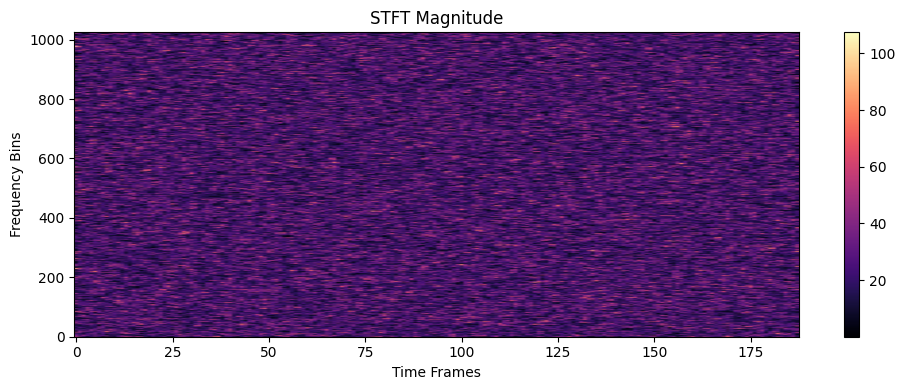

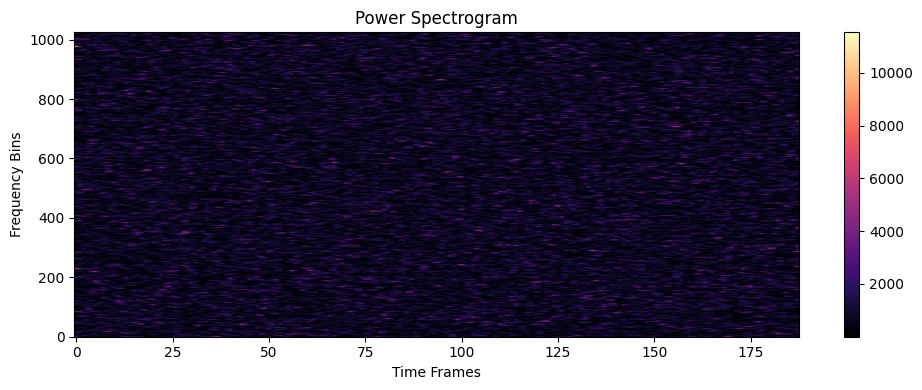

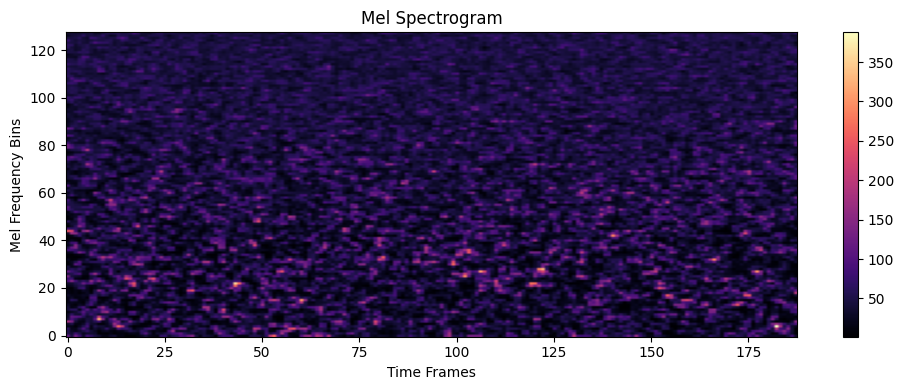

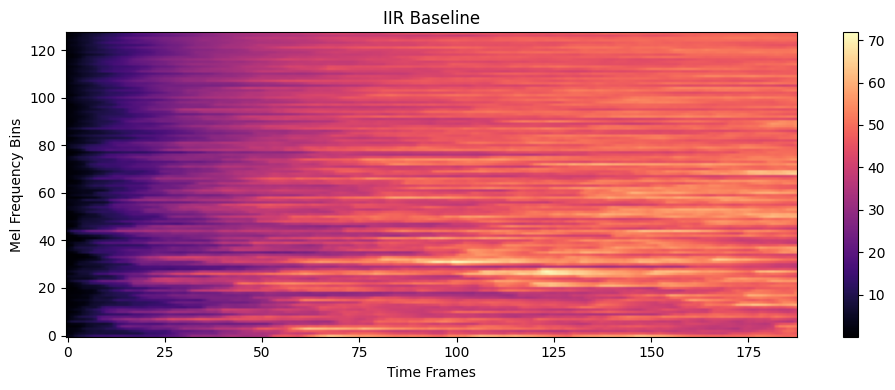

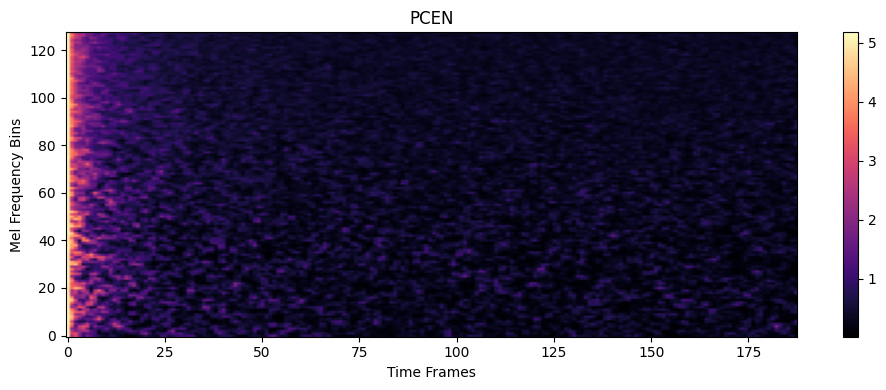

In [32]:
mel_pcen = TorchMelPCEN(cfg).to(cfg.device)

test_wave = torch.randn(1, cfg.clip_samples, device=cfg.device)

visualize_pipeline(mel_pcen, test_wave)

# SpecAugment (Time & Frequency Masking)

In [33]:
import random

class TorchSpecAugment(nn.Module):
    def __init__(self, config: Config = cfg):
        super().__init__()
        self.F = config.freq_mask_param
        self.T = config.time_mask_param
        self.nF = config.num_freq_masks
        self.nT = config.num_time_masks


    def forward(self, spec: torch.Tensor)-> torch.Tensor:
        """
        Input & Output: (Batch, 1, N_MELS, Time_Frames)
        """
        spec = spec.clone()
        B, _, n_mels, n_frames = spec.shape

        # Apply independent masks per sample for better augmentation diversity
        for b in range(B):
            for _ in range(self.nF):
                f = random.randint(0, self.F)
                f0 = random.randint(0, max(0, n_mels - f))
                spec[b, :, f0 : f0 + f, :] = 0.0

            for _ in range(self.nT):
                t = random.randint(0, self.T)
                t0 = random.randint(0, max(0, n_frames - t))
                spec[b, :, :, t0 : t0 + t] = 0.0

        return spec

# Dataset & Acousitic Mixup Collator

In [34]:
import numpy as np
import pandas as pd
import soundfile as sf
import torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

class BirdAudioDataset(Dataset):
    def __init__(self, clips_csv: str, split: str = "train", config: Config = cfg, audio_root: str = None):
        self.split = split
        self.config = config
        df = pd.read_csv(clips_csv)

        self.df = df[df["split"] == split].reset_index(drop=True)

        # Re-route local path to Kaggle dataset path
        if audio_root is not None:
            audio_root = Path(audio_root)
            def fix_path(old_path):
                old = Path(old_path)
                parts = old.parts
                if "clips" in parts:
                    idx = parts.index("clips")
                    return str(audio_root / Path(*parts[idx:]))
                return str(audio_root / "clips" / old.name)
            
            self.df["clip_path"] = self.df["clip_path"].apply(fix_path)

        all_species = sorted(df["species"].unique())
        self.species_to_idx = {s: i for i, s in enumerate(all_species)}
        self.idx_to_species = {i: s for s, i in self.species_to_idx.items()}
        self.num_classes = len(all_species)

        # Class counts for loss re-weighting
        self.class_counts = np.zeros(self.num_classes, dtype=np.int64)
        for species, grp in df[df["split"] == "train"].groupby("species"):
            idx = self.species_to_idx[species]
            self.class_counts[idx] = len(grp)

    def _load_and_pad(self, audio_path: str) -> np.ndarray:
        try:
            audio, _ = sf.read(audio_path, dtype="float32")
        except Exception as e:
            # Fallback if audio corrupted
            audio = np.zeros(self.config.clip_samples, dtype=np.float32)

        if len(audio) < self.config.clip_samples:
            audio = np.pad(audio, (0, self.config.clip_samples - len(audio)))
        elif len(audio) > self.config.clip_samples:
            if self.split == "train":
                start = random.randint(0, len(audio) - self.config.clip_samples)
                audio = audio[start : start + self.config.clip_samples]
            else:
                audio = audio[: self.config.clip_samples]
        return audio

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx]
        waveform = self._load_and_pad(row["clip_path"])
        label = self.species_to_idx[row["species"]]
        rec_id = str(row.get("recording_id", idx))

        return {
            "waveform": torch.from_numpy(waveform),
            "label": torch.tensor(label, dtype=torch.long),  # Fixed: torch.long
            "recording_id": rec_id,
        }

In [35]:
class MixupCollator:
    def __init__(self, num_classes: int, alpha: float = cfg.mixup_alpha, prob: float = cfg.mixup_prob):
        self.num_classes = num_classes
        self.alpha = alpha
        self.prob = prob

    def __call__(self, batch: list[dict])-> dict:
        waveforms = torch.stack([b["waveform"] for b in batch])
        labels = torch.tensor([b["label"] for b in batch], dtype=torch.long)
        recording_ids = [b["recording_id"] for b in batch]

        # Convert discrete labels to one-hot float targets
        one_hot = torch.zeros(len(batch), self.num_classes, dtype=torch.float32)
        one_hot.scatter_(1, labels.unsqueeze(1), 1.0)

        if np.random.rand() > self.prob:
            return {"waveform": waveforms, "label": one_hot, "recording_id": recording_ids}

        # Mixup logic
        perm = torch.randperm(len(batch))
        lam = float(np.random.beta(self.alpha, self.alpha))

        mixed_waveforms = lam * waveforms + (1.0 - lam) * waveforms[perm]
        mixed_labels = lam * one_hot + (1.0 - lam) * one_hot[perm]

        return {"waveform": mixed_waveforms, "label": mixed_labels, "recording_id": recording_ids}

# Audio spectrogram Transformer (AST) Architecture

In [36]:
import re
import torch.nn.functional as F
from transformers import ASTForAudioClassification

class ASTBirdClassifier(nn.Module):
    def __init__(self, 
                 num_classes: int = cfg.num_classes, 
                 dropout: float = cfg.stage2_dropout,
                 freeze_layers: int = cfg.stage1_freeze_layers,
                 config: Config = cfg
                ):
        super().__init__()
        self.num_classes = num_classes
        self.target_time_frames = config.ast_target_frames

        # 1. Load AudioSet-pretrained backbone (replaces 527 AudioSet classes with our classes)
        self.ast = ASTForAudioClassification.from_pretrained(
            config.pretrained_ast_name,
            num_labels = num_classes,
            ignore_mismatched_sizes=True,
        )

        # 2. Gradient Checkpointing: Recomputes activations during backward pass to save VRAM
        # recomputing some activations instead of storing them.

        #3. Add regularization Dropout before classification head
        if dropout > 0.0:
            orig_dense = self.ast.classifier.dense
            self.ast.classifier.dense = nn.Sequential(nn.Dropout(p=dropout), orig_dense)

        # 4. Freeze bottom layers for initial stage warmup
        if freeze_layers > 0:
            self.freeze_bottom_layers(freeze_layers)

    def freeze_bottom_layers(self, n_layers: int):
        """Freezes patch embeddings and the first n_layers of the 12 encoder blocks."""
        for name, param in self.ast.named_parameters():
            if "embeddings" in name:
                param.requires_grad = False
            elif "encoder" in name:
                match = re.search(r"layers[s]?[.\[_](\d+)]", name)
                if match and int(match.group(1)) < n_layers:
                    param.requires_grad = False

    def enable_gradient_checkpointing(self):
        """Enable gradient checkpointing — only safe on single GPU (incompatible with DataParallel)."""
        self.ast.gradient_checkpointing_enable()

    def unfreeze_all_layers(self):
        """Unfreezes all layers for full end-to-end fine-tuning."""
        for param in self.ast.parameters():
            param.requires_grad = True

    def forward(self, spec: torch.Tensor)-> torch.Tensor:
        """
        Input:  spec of shape (Batch, 1, 128, Time_Frames)
        Output: logits of shape (Batch, num_classes)
        """
        # Shape: (Batch, Time_Frames, N_MELS)
        x = spec.squeeze(1).transpose(1, 2)
        # Pad time frames to match AST's 1024 positional embedding length
        t_frames = x.shape[1]
        if t_frames < self.target_time_frames:
            pad = self.target_time_frames - t_frames
            x = F.pad(x, (0, 0, 0, pad))
        elif t_frames > self.target_time_frames:
            x = x[:, : self.target_time_frames, :]

        # Forward pass through AST
        outputs = self.ast(input_values=x)
        return outputs.logits
        

# Class Balanced BCE Loss & Metrics

In [37]:
class ClassBalancedBCELoss(nn.Module):
    def __init__(self, class_counts:np.ndarray | None = None, beta:float = 0.999):
        super().__init__()
        pos_weight = None
        if class_counts is not None:
            counts = np.maximum(class_counts, 1)
            effective_num = 1.0 - np.power(beta, counts)
            weights = (1.0 - beta) / np.array(effective_num)
            weights = weights / np.mean(weights)
            weights = np.clip(weights, 1.0, 25.0) # Bound
            pos_weight = torch.tensor(weights, dtype=torch.float32)

        self.loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.label_smoothing = label_smoothing
    
    def forward(self, logits: torch.Tensor, targets: torch.Tensor)-> torch.Tensor:
        if targets.ndim == 1:
            targets = F.one_hot(targets, num_classes=logits.shape[-1]).float()
        return self.loss_fn(logits, targets)

def compute_metrics(logits: torch.Tensor, targets: torch.Tensor)-> tuple[float, float]:
    """Computes Top-1 and Top-5 Accuracy"""
    with torch.no_grad():
        target_indices = targets.argmax(dim=1) if targets.ndim > 1 else targets
        _, top5 = logits.topk(5, dim=1)
        top1_correct = (top5[:,0] == target_indices).sum().item()
        top5_correct = (top5 == target_indices.unsqueeze(1)).any(dim=1).sum().item()
        n = len(targets)
        return top1_correct / max(n,1), top5_correct / max(n,1)

# The 2-Stage Training Loop

In [38]:
from tqdm.auto import tqdm
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

def run_training_stage(
    stage_num: int,
    epochs: int,
    lr: float,
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    mel_pcen: nn.Module,
    spec_aug: nn.Module,
    patience: int = 4,
    device: str = cfg.device
):
    print(f"\n{'='*20} STARTING STAGE {stage_num} ({epochs} Epochs | LR={lr}) {'='*20}")
    
    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=1e-2 if stage_num == 2 else 1e-3
    )
    warmup_epochs = max(1, min(5, epochs // 5))
    from torch.optim.lr_scheduler import LinearLR, SequentialLR
    _warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
    _cosine = CosineAnnealingLR(optimizer, T_max=max(1, epochs - warmup_epochs), eta_min=1e-6)
    scheduler = SequentialLR(optimizer, schedulers=[_warmup, _cosine], milestones=[warmup_epochs])
    scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

    best_val_top1 = 0.0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        # ── 1. Training Phase ──────────────────────────────────────────
        model.train()
        train_loss, train_top1, total_samples = 0.0, 0.0, 0

        # Live tqdm progress bar for training batches
        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{epochs:02d} [Train]", leave=False)
        for batch in pbar:
            waveforms = batch["waveform"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            with torch.no_grad():
                specs = mel_pcen(waveforms)
                specs = spec_aug(specs)

            optimizer.zero_grad()
            with torch.amp.autocast("cuda", enabled=(device == "cuda")):
                logits = model(specs)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            batch_top1, _ = compute_metrics(logits, labels)
            bs = len(labels)
            train_loss += loss.item() * bs
            train_top1 += batch_top1 * bs
            total_samples += bs

            # Update live stats on the progress bar
            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{(train_top1 / total_samples)*100:.1f}%"
            })

        train_loss /= total_samples
        train_top1 /= total_samples

        # ── 2. Validation Phase ────────────────────────────────────────
        model.eval()
        val_loss, val_top1, val_top5, total_val = 0.0, 0.0, 0.0, 0

        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch:02d}/{epochs:02d} [Val]", leave=False)
        with torch.no_grad():
            for batch in val_pbar:
                waveforms = batch["waveform"].to(device, non_blocking=True)
                labels = batch["label"].to(device, non_blocking=True)

                with torch.amp.autocast("cuda", enabled=(device == "cuda")):
                    specs = mel_pcen(waveforms)
                    logits = model(specs)
                # Compute loss in fp32 outside autocast to prevent NaN
                loss = criterion(logits.float(), labels)

                b_top1, b_top5 = compute_metrics(logits, labels)
                bs = len(labels)
                val_loss += loss.item() * bs
                val_top1 += b_top1 * bs
                val_top5 += b_top5 * bs
                total_val += bs

                val_pbar.set_postfix({"val_loss": f"{loss.item():.4f}"})

        val_loss /= total_val
        val_top1 /= total_val
        val_top5 /= total_val

        scheduler.step()

        # Summary line after each epoch
        print(
            f"Epoch {epoch:02d}/{epochs:02d} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_top1*100:.1f}% | "
            f"Val Loss: {val_loss:.4f} Top-1: {val_top1*100:.2f}% Top-5: {val_top5*100:.2f}%"
        )

        # ── 3. Checkpointing & Early Stopping ──────────────────────────
        if val_top1 > best_val_top1:
            best_val_top1 = val_top1
            patience_counter = 0
            _state = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
            torch.save(_state, f"best_stage{stage_num}_model.pt")
            print(f"  >>> Best model saved (Top-1: {val_top1*100:.2f}%)")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  ⏹️ Early stopping at epoch {epoch}! Best Val Top-1: {best_val_top1*100:.2f}%")
                break

    # Reload best checkpoint for next stage
    _ckpt = torch.load(f"best_stage{stage_num}_model.pt", map_location=device)
    if hasattr(model, "module"):
        model.module.load_state_dict(_ckpt)
    else:
        model.load_state_dict(_ckpt)
    return best_val_top1

# Benchmark Evaluation with Temporal Mean Pooling

In [39]:
from collections import defaultdict

def evaluate_recording_level(model: nn.Module, test_loader: DataLoader, mel_pcen: nn.Module, device: str = cfg.device):
    model.eval()
    rec_probs = defaultdict(list)
    rec_targets = {}

    print(f"Running inference across {len(test_loader.dataset)} clips...")

    with torch.no_grad():
        for batch in test_loader:
            waveforms = batch["waveform"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)
            rec_ids = batch["recording_id"]

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            specs = mel_pcen(waveforms)
            logits = model(specs)
        probs = torch.sigmoid(logits)
        
        for r_id, p, l in zip(rec_ids, probs, labels):
            rec_probs[r_id].append(p)
            if r_id not in rec_targets:
                rec_targets[r_id] = l.argmax().item() if l.ndim > 0 else l.item()

    # Aggregate clip predictions per recording via Mean Pooling
    rec_top1 = 0
    rec_top5 = 0
    total_recs = len(rec_probs)

    for r_id, p_list in rec_probs.items():
        avg_prob = torch.stack(p_list).mean(dim=0)
        target = rec_targets[r_id]
        _, top5_indices = avg_prob.topk(5)

        if top5_indices[0].item() == target:
            rec_top1 += 1
        if target in top5_indices.tolist():
            rec_top5 += 1

    print("\n" + "="*50)
    print(f"RECORDING-LEVEL RESULTS ({total_recs} unique field recordings):")
    print(f"  Top-1 Accuracy: {rec_top1 / total_recs * 100:.2f}%")
    print(f"  Top-5 Accuracy: {rec_top5 / total_recs * 100:.2f}%")
    print("="*50)

# Execution Pipeline (Run Everything)

In [40]:
import os
print(os.listdir("/kaggle/input"))
print(os.listdir("/kaggle/input/datasets"))
print(os.listdir("/kaggle/input/datasets/routinemotiv"))
print(os.listdir("/kaggle/input/datasets/routinemotiv/forest-dataset/outputs"))
print(os.listdir("/kaggle/input/datasets/routinemotiv/forest-dataset/outputs/extraction"))
print(os.listdir("/kaggle/input/datasets/routinemotiv/forest-dataset/outputs/extraction/clips"))

['datasets']
['routinemotiv']
['forest-dataset']
['extraction', 'nepal_bird_filtered.csv']
['clips_metadata.csv', 'clips']
['val', 'test', 'train']


In [41]:
CLIPS_CSV = "/kaggle/input/datasets/routinemotiv/forest-dataset/outputs/extraction/clips_metadata.csv"
AUDIO_ROOT = "/kaggle/input/datasets/routinemotiv/forest-dataset/outputs/extraction"

# 1. Initialize Datasets & DataLoaders
train_dataset = BirdAudioDataset(clips_csv=CLIPS_CSV, split="train", audio_root=AUDIO_ROOT)
val_dataset = BirdAudioDataset(clips_csv=CLIPS_CSV, split="val", audio_root=AUDIO_ROOT)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    collate_fn=MixupCollator(num_classes=train_dataset.num_classes)
)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False)

print(f"✓ Train dataset size: {len(train_dataset)}")
print(f"✓ Val dataset size:   {len(val_dataset)}")
print(f"✓ Species classes:    {train_dataset.num_classes}")

# 2. Initialize Front-End and Loss
mel_pcen = TorchMelPCEN(cfg).to(cfg.device)
spec_aug = TorchSpecAugment(cfg).to(cfg.device)
criterion = ClassBalancedBCELoss(class_counts=train_dataset.class_counts).to(cfg.device)

# 3. Build Model (Stage 1: Frozen bottom 8 layers)
model = ASTBirdClassifier(
    num_classes=train_dataset.num_classes,
    freeze_layers=cfg.stage1_freeze_layers
).to(cfg.device)
# Gradient checkpointing incompatible with DataParallel
if torch.cuda.device_count() <= 1:
    model.enable_gradient_checkpointing()
    print("Gradient checkpointing enabled (single-GPU mode).")
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs via DataParallel (gradient checkpointing disabled).")
    model = torch.nn.DataParallel(model)

# 4. Run Stage 1 (Warmup)
run_training_stage(
    stage_num=1,
    epochs=cfg.stage1_epochs,
    lr=cfg.stage1_lr,
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    mel_pcen=mel_pcen,
    spec_aug=spec_aug
)

# 5. Unfreeze for Stage 2 (Full fine-tuning)
if hasattr(model, "module"):
    model.module.unfreeze_all_layers()
else:
    model.unfreeze_all_layers()
run_training_stage(
    stage_num=2,
    epochs=cfg.stage2_epochs,
    lr=cfg.stage2_lr,
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    mel_pcen=mel_pcen,
    spec_aug=spec_aug
)

# 6. Benchmark with Temporal Mean Pooling
evaluate_recording_level(model, val_loader, mel_pcen)

✓ Train dataset size: 24664
✓ Val dataset size:   4324
✓ Species classes:    292


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                         
------------------------+----------+-----------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([292])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([292, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.



==================== STARTING STAGE 1 (15 Epochs | LR=0.0005) ====================


Epoch 01/15 [Train]:   0%|          | 0/1542 [00:00<?, ?it/s]

KeyboardInterrupt: 